In [1]:
import sys
import os
from pathlib import Path  # noqa: F401

# Resolve project root regardless of where the notebook is launched from
for _candidate in [".", "..", "../.."]:
    _p = os.path.abspath(_candidate)
    if os.path.isdir(os.path.join(_p, "src")):
        sys.path.insert(0, _p)
        break

import zipfile  # noqa: E402
import numpy as np  # noqa: E402
import numpy.lib.format as npformat  # noqa: E402
import pandas as pd  # noqa: E402
import matplotlib.pyplot as plt  # noqa: E402
import seaborn as sns  # noqa: E402
import mne  # noqa: E402
from scipy.stats import zscore  # noqa: E402

from src.preprocessing.pipeline import DatasetHandler  # noqa: E402
from src.definitions.fields import (  # noqa: E402
    ConditionVariants,
    MusicTypeVariants,
    ExperimentNames,
    CoordinateSystems,
    PreprocessedDataVariants,
)
from src.definitions.constants import ProjectPaths  # noqa: E402

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
mne.set_log_level("ERROR")
print("Setup complete.")

Setup complete.


# ASSR Stimulus-Locked Inspection — Raw & Wavelet (after alignment)

Inspect the **stimulus-aligned** ASSR data that feeds the analyses, to spot
per-participant outliers. Two representations are compared, both **averaged over
stimuli** (every `fam+` onset) and viewed *per participant* and *averaged over
participants*:

1. **Raw signal** (`concatenated/Placebo_ASSR.npy`) — the z-scored mean signal in
   time, stimulus-locked. Outliers show up as participants whose evoked waveform
   has an odd shape or amplitude.
2. **Wavelet power** (`wavelets/broadband/…freqdim1.npz`) — the stimulus-locked
   time-frequency power map (z-scored). The 40 Hz auditory steady-state response
   should appear as a sustained band; outliers deviate from the group map.

The stimulus alignment (see `00-preprocessing/stimulus_alignment.ipynb`) splices
every recording so each onset lands at the **same sample index** in all
participants — the onsets are therefore a single shared array, valid for every
subject and for both representations.

> **Small-subset notebook by design.** The wavelet file is ~49 GB
> (`(15, 195×50, 47451)` float64), far too large to load whole, so it is read
> **lazily** — only the selected subjects/channels are decompressed. Keep
> `SUBJECT_INDICES` to the *lowest* indices: the streaming reader must scan from
> the start of the array, so reading subjects `[0, 1, 2]` is far cheaper than
> `[0, 7, 14]`.

## Configuration

In [2]:
EXPERIMENT = ExperimentNames.ASSR
CONDITION = ConditionVariants.PLACEBO   # default per project convention
MUSIC_TYPE = MusicTypeVariants.ASSR

# ── Small subset to inspect ───────────────────────────────────────────────
# Subject indices into the concatenated array (CONCATENATED_PERSON_INDEX). Keep
# these LOW — the lazy wavelet reader scans from the start, so [0, 1, 2] only
# decompresses the first 3 of 15 subject blocks.
SUBJECT_INDICES = [0, 1, 2]
# A handful of electrodes (by name). Central / fronto-central sites carry the
# clearest 40 Hz ASSR; Cz is the canonical channel. Missing names are dropped.
CHANNELS = ["Cz", "E7", "E55", "E106", "E80"]

# ── Stimulus-locked epoch window (seconds, relative to each fam+ onset) ────
EPOCH_TMIN = -0.1
EPOCH_TMAX = 1.2            # ~ inter-onset interval (median gap ≈ 1.28 s); a few
                           # samples of overlap at the tightest gap is harmless
ASSR_FREQ = 40.0           # expected steady-state frequency (Hz)
SFREQ = 250.0              # sampling rate of the concatenated / wavelet data

# Topomap = stimulus-locked z-scored wavelet power, mean-collapsed over this
# post-onset window (s) and frequency range (Hz). Default: broadband 1-50 Hz over
# the whole post-onset window. Narrow TOPO_FREQ_RANGE to e.g. (38, 42) for an
# ASSR-band-specific topography.
TOPO_TMIN, TOPO_TMAX = 0.0, EPOCH_TMAX
TOPO_FREQ_RANGE = (1.0, 50.0)

# ── Wavelet cache descriptor (matches the stored filename) ─────────────────
WAVELET_FREQ_SIG = "1.000_50.000_50"   # freqs[0]_freqs[-1]_n_freqs
N_WAVELET_FREQS = 50

# ── Plot saving ────────────────────────────────────────────────────────────
SAVE_PLOTS = True
PLOTS_DIR = (
    ProjectPaths.NOTEBOOKS_DIR
    / "00-preprocessing"
    / "plots"
    / "assr_stimulus_aligned_inspection"
    / f"{CONDITION.value}_{MUSIC_TYPE.value}"
)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Group           : {CONDITION.value} / {MUSIC_TYPE.value}")
print(f"Subjects        : {SUBJECT_INDICES}")
print(f"Channels        : {CHANNELS}")
print(f"Epoch window    : [{EPOCH_TMIN}, {EPOCH_TMAX}] s")
print(f"Plots -> {PLOTS_DIR}")

Group           : Placebo / ASSR
Subjects        : [0, 1, 2]
Channels        : ['Cz', 'E7', 'E55', 'E106', 'E80']
Epoch window    : [-0.1, 1.2] s
Plots -> /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/notebooks/00-preprocessing/plots/assr_stimulus_aligned_inspection/Placebo_ASSR


## Load Concatenated Data, Onsets & Metadata

In [3]:
safe_label = f"{CONDITION.value}_{MUSIC_TYPE.value}"

concat_dir = (
    ProjectPaths.PROCESSED_DATA_DIR
    / EXPERIMENT.value
    / PreprocessedDataVariants.CONCATENATED.value
)
raw_path = concat_dir / f"{safe_label}.npy"
onsets_path = concat_dir / f"{safe_label}{ProjectPaths.STIMULUS_ONSETS_SUFFIX}"
meta_path = concat_dir / f"{safe_label}.metadata.csv"

wavelet_path = (
    ProjectPaths.PROCESSED_DATA_DIR
    / EXPERIMENT.value
    / "wavelets"
    / "broadband"
    / f"{safe_label}__wavelet_power__{WAVELET_FREQ_SIG}__freqdim1.npz"
)
for p in (raw_path, onsets_path, meta_path, wavelet_path):
    assert p.exists(), f"Missing expected file: {p}"

# Raw concatenated array, memory-mapped (1.1 GB) so only the selected
# subjects/channels are ever read into memory.
raw_mm = np.load(raw_path, mmap_mode="r")          # (n_subj, n_ch, n_times)
onsets = np.load(onsets_path)                        # (n_onsets,) shared sample idx
meta = pd.read_csv(meta_path, index_col=0)

n_subj_total, n_channels, n_times_raw = raw_mm.shape
print(f"Concatenated raw : {raw_mm.shape}  (dtype {raw_mm.dtype})")
print(f"Stimulus onsets  : {onsets.shape}  range [{onsets.min()}, {onsets.max()}], "
      f"median gap {int(np.median(np.diff(onsets)))} samples")

# Channel names are stored in the wavelet feature_names (layout: channel*N_FREQS).
# The concatenated raw shares the same channel order (same pipeline), so one set
# of names indexes both.
with zipfile.ZipFile(wavelet_path) as _z:
    with _z.open("feature_names.npy") as _f:
        feature_names = npformat.read_array(_f, allow_pickle=True)
channel_names = [str(feature_names[i * N_WAVELET_FREQS]).split("@")[0]
                 for i in range(len(feature_names) // N_WAVELET_FREQS)]
assert len(channel_names) == n_channels, (
    f"channel-name count {len(channel_names)} != raw n_channels {n_channels}"
)
print(f"Channels parsed  : {len(channel_names)} (first={channel_names[0]}, "
      f"last={channel_names[-1]})")
meta[["SingleDataMetadata.PARTICIPANT_ID", "SingleDataMetadata.CONDITION",
      "SingleDataMetadata.CONCATENATED_PERSON_INDEX"]].head()

Concatenated raw : (15, 195, 47460)  (dtype float64)
Stimulus onsets  : (148,)  range [125, 47146], median gap 319 samples
Channels parsed  : 195 (first=E1, last=Cz)


,SingleDataMetadata.PARTICIPANT_ID,SingleDataMetadata.CONDITION,SingleDataMetadata.CONCATENATED_PERSON_INDEX
0,31,ConditionVariants.PLACEBO,0
1,39,ConditionVariants.PLACEBO,1
2,38,ConditionVariants.PLACEBO,2
8,36,ConditionVariants.PLACEBO,3
10,34,ConditionVariants.PLACEBO,4


## Subset Selection

In [4]:
# Resolve the requested channel names to indices (drop any that are absent).
name_to_idx = {name: i for i, name in enumerate(channel_names)}
missing = [c for c in CHANNELS if c not in name_to_idx]
if missing:
    print(f"WARNING: channels not found and skipped: {missing}")
channel_indices = [name_to_idx[c] for c in CHANNELS if c in name_to_idx]
sel_channel_names = [channel_names[i] for i in channel_indices]
assert channel_indices, "No valid channels selected."

# Map subject indices -> participant labels via the concatenated metadata.
pidx_col = "SingleDataMetadata.CONCATENATED_PERSON_INDEX"
pid_col = "SingleDataMetadata.PARTICIPANT_ID"
idx_to_pid = dict(zip(meta[pidx_col], meta[pid_col].astype(str).str.zfill(3)))
subject_labels = [f"PSI{idx_to_pid.get(si, '???')}" for si in SUBJECT_INDICES]

# Epoch window in samples.
PRE = int(round(-EPOCH_TMIN * SFREQ))
POST = int(round(EPOCH_TMAX * SFREQ))
epoch_times = np.arange(-PRE, POST) / SFREQ        # (win,) seconds, t=0 at onset

print(f"Selected channels: {sel_channel_names} -> idx {channel_indices}")
print(f"Selected subjects: {dict(zip(SUBJECT_INDICES, subject_labels))}")
print(f"Epoch length     : {PRE + POST} samples ({PRE} pre, {POST} post)")

Selected channels: ['Cz', 'E7', 'E55', 'E106', 'E80'] -> idx [194, 6, 54, 98, 77]
Selected subjects: {0: 'PSI031', 1: 'PSI039', 2: 'PSI038'}
Epoch length     : 325 samples (25 pre, 300 post)


## Helpers — epoching & lazy wavelet reader

In [5]:
def epoch_average(arr, onsets, pre, post):
    """Average fixed windows around each onset along the LAST axis.

    Args:
        arr: array whose last axis is time, e.g. ``(n_channels, n_times)`` or
            ``(n_channels, n_freqs, n_times)``.
        onsets: stimulus onset sample indices.
        pre, post: samples kept before / after each onset (window = pre + post).

    Returns:
        Array with the time axis replaced by the ``pre + post`` window, averaged
        over all onsets whose window fits inside the recording.
    """
    n_time = arr.shape[-1]
    acc = None
    n_used = 0
    for o in onsets:
        s, e = o - pre, o + post
        if s < 0 or e > n_time:
            continue
        seg = arr[..., s:e]
        acc = seg.astype(np.float64) if acc is None else acc + seg
        n_used += 1
    if n_used == 0:
        raise ValueError("No onset window fits inside the recording.")
    return acc / n_used, n_used


def load_wavelet_power_subset(npz_path, subject_indices, channel_indices,
                              n_channels, n_freqs, *, onsets=None, pre=None,
                              post=None, topo_freq_mask=None, topo_post_mask=None):
    """Lazily read selected blocks from a huge wavelet npz, optionally reducing all.

    ``savez_compressed`` stores ``data.npy`` as a single deflate stream, so it
    cannot be sliced randomly — it must be decompressed sequentially. This reader
    streams one (channel, all-freqs) block at a time. Peak memory is one block
    (~19 MB), so the 49 GB file never lands in RAM.

    It always keeps the full ``(n_freqs, n_times)`` block for the requested
    ``channel_indices`` (for the time-frequency maps). When ``onsets``/``pre``/
    ``post`` and the ``topo_*`` masks are supplied, it *also* reduces **every**
    channel of each selected subject to one scalar topomap value — the wavelet
    power **z-scored in time**, stimulus-locked averaged, then mean-collapsed over
    the selected frequencies and post-onset window (signed; no powering / sqrt).
    Because advancing the stream already decompresses every channel block, this
    all-channel reduction is essentially free (one pass, not two).

    Returns ``(data, n_times, topo)`` where ``data`` has shape
    ``(len(subject_indices), len(channel_indices), n_freqs, n_times)`` and ``topo``
    maps subject idx -> ``(n_channels,)`` (or ``None`` when no reduction requested).
    """
    compute_topo = onsets is not None and topo_freq_mask is not None
    subj_set, ch_set = set(subject_indices), set(channel_indices)
    max_subj = max(subject_indices)
    max_ch = max(channel_indices)
    collected = {si: {} for si in subject_indices}
    topo = (
        {si: np.full(n_channels, np.nan) for si in subject_indices}
        if compute_topo else None
    )
    with zipfile.ZipFile(npz_path) as z:
        with z.open("data.npy") as f:
            ver = npformat.read_magic(f)
            if ver == (1, 0):
                shape, _, dtype = npformat.read_array_header_1_0(f)
            else:
                shape, _, dtype = npformat.read_array_header_2_0(f)
            n_subj_total, n_feat_flat, n_times = shape
            assert n_feat_flat == n_channels * n_freqs, (
                f"feature axis {n_feat_flat} != n_channels*n_freqs "
                f"{n_channels * n_freqs}"
            )
            block_bytes = n_freqs * n_times * dtype.itemsize  # one channel block
            done = False
            for s in range(max_subj + 1):
                for c in range(n_channels):
                    buf = f.read(block_bytes)
                    if s in subj_set:
                        block = np.frombuffer(
                            buf, dtype=dtype, count=n_freqs * n_times
                        ).reshape(n_freqs, n_times)
                        if c in ch_set:
                            collected[s][c] = block.copy()
                        if compute_topo:
                            zp = zscore(block, axis=1)        # z-score power in time
                            ev, _ = epoch_average(zp, onsets, pre, post)  # (f, win)
                            topo[s][c] = ev[topo_freq_mask][:, topo_post_mask].mean()
                    # Early stop only when not reducing every channel.
                    if not compute_topo and s == max_subj and c == max_ch:
                        done = True
                        break
                if done:
                    break
                if s in subj_set:
                    print(f"  scanned subject block {s} ...")
    data = np.stack(
        [np.stack([collected[s][c] for c in channel_indices])
         for s in subject_indices]
    )
    return data, n_times, topo


print("Helpers defined.")

Helpers defined.


## Raw Stimulus-Locked Mean Signal

For each selected participant: z-score every selected channel **in time** over the
whole recording, epoch around each `fam+` onset, average across stimuli, then
average across the selected channels — giving one stimulus-locked mean waveform per
participant. The bold black line is the **average over participants**. A participant
whose waveform sits far from the rest (shape or amplitude) is a candidate outlier.

Averaged 148 stimuli per participant.


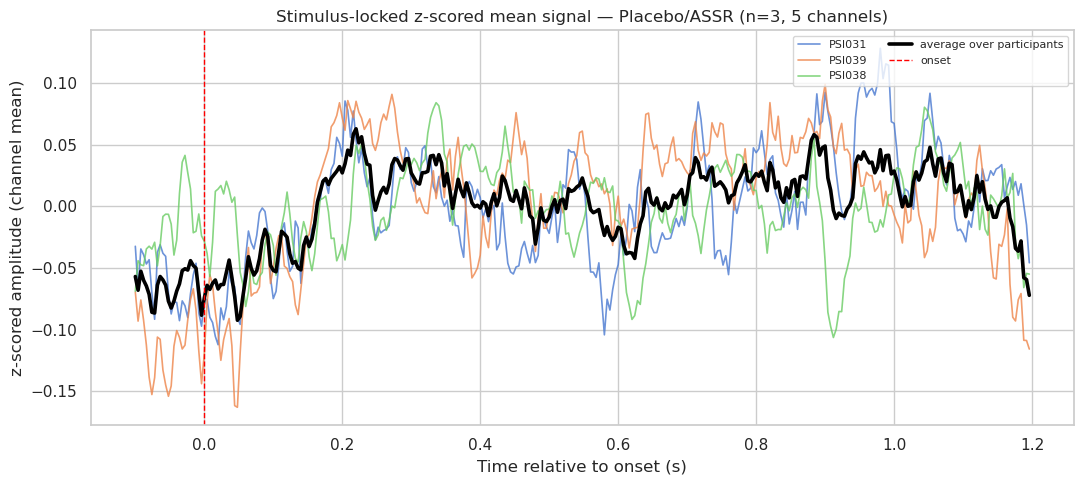

In [6]:
raw_curves = {}        # subject idx -> (win,) stimulus-locked mean signal
for si in SUBJECT_INDICES:
    d = np.asarray(raw_mm[si][channel_indices])      # (n_sel_ch, n_times)
    z = zscore(d, axis=1)                            # z-score each channel in time
    ep, n_used = epoch_average(z, onsets, PRE, POST)  # (n_sel_ch, win)
    raw_curves[si] = ep.mean(axis=0)                 # average across channels
group_curve = np.mean([raw_curves[si] for si in SUBJECT_INDICES], axis=0)
print(f"Averaged {n_used} stimuli per participant.")

fig, ax = plt.subplots(figsize=(11, 5))
for si, label in zip(SUBJECT_INDICES, subject_labels):
    ax.plot(epoch_times, raw_curves[si], lw=1.2, alpha=0.8, label=label)
ax.plot(epoch_times, group_curve, lw=2.6, color="black",
        label="average over participants")
ax.axvline(0.0, color="red", ls="--", lw=1, label="onset")
ax.set_title(
    f"Stimulus-locked z-scored mean signal — {CONDITION.value}/{MUSIC_TYPE.value} "
    f"(n={len(SUBJECT_INDICES)}, {len(sel_channel_names)} channels)"
)
ax.set_xlabel("Time relative to onset (s)")
ax.set_ylabel("z-scored amplitude (channel mean)")
ax.legend(loc="upper right", fontsize=8, ncol=2)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "raw_stimulus_locked_mean_signal.png", dpi=150)
plt.show()

### Per-Participant Stimulus-Locked Mean Signal (one panel each)

The same z-scored stimulus-locked mean signals as above, but one panel per
participant (group average dashed for reference), so an individual waveform can be
read on its own without the overlay clutter.

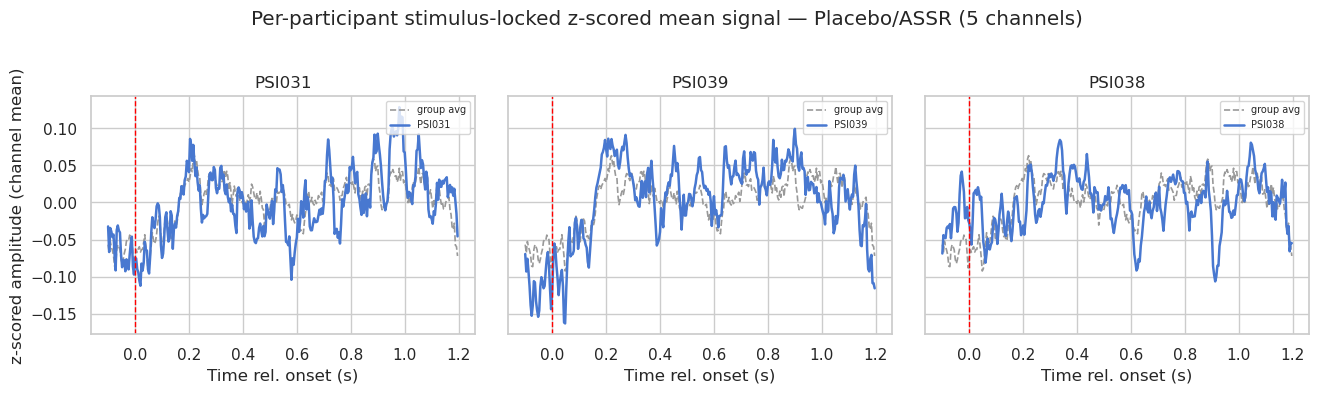

In [7]:
fig, axes = plt.subplots(
    1, len(SUBJECT_INDICES), figsize=(4.5 * len(SUBJECT_INDICES), 3.8),
    sharey=True, squeeze=False,
)
for ax, si, label in zip(axes[0], SUBJECT_INDICES, subject_labels):
    ax.plot(epoch_times, group_curve, lw=1.2, color="0.6", ls="--",
            label="group avg")
    ax.plot(epoch_times, raw_curves[si], lw=1.8, color="C0", label=label)
    ax.axvline(0.0, color="red", ls="--", lw=1)
    ax.set_title(label)
    ax.set_xlabel("Time rel. onset (s)")
    ax.legend(loc="upper right", fontsize=7)
axes[0][0].set_ylabel("z-scored amplitude (channel mean)")
fig.suptitle(
    f"Per-participant stimulus-locked z-scored mean signal — "
    f"{CONDITION.value}/{MUSIC_TYPE.value} ({len(sel_channel_names)} channels)",
    y=1.03,
)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "raw_stimulus_locked_mean_signal_per_participant.png",
                dpi=150, bbox_inches="tight")
plt.show()

## Wavelet Power — lazy load of the subset

Stream only the selected subjects/channels out of the 49 GB wavelet cache. This
decompresses sequentially from the start of the file, so it takes a little while
(progress is printed per subject block); the result is a small
`(n_subj, n_channels, n_freqs, n_times)` array.

In [8]:
wavelet_freqs = np.arange(1.0, N_WAVELET_FREQS + 1.0)   # 1..50 Hz (as cached)

# Reduction masks for the all-channel topomap (computed in the same streaming
# pass): post-onset time window and the frequencies to collapse over.
topo_post_mask = (epoch_times >= TOPO_TMIN) & (epoch_times <= TOPO_TMAX)
topo_freq_mask = (
    (wavelet_freqs >= TOPO_FREQ_RANGE[0]) & (wavelet_freqs <= TOPO_FREQ_RANGE[1])
)

wav, n_times_wav, wav_topo = load_wavelet_power_subset(
    wavelet_path,
    subject_indices=SUBJECT_INDICES,
    channel_indices=channel_indices,
    n_channels=n_channels,
    n_freqs=N_WAVELET_FREQS,
    onsets=onsets,
    pre=PRE,
    post=POST,
    topo_freq_mask=topo_freq_mask,
    topo_post_mask=topo_post_mask,
)
print(f"Loaded wavelet subset: {wav.shape}  (n_times={n_times_wav})")
print(f"All-channel topomap reduction: {len(wav_topo)} subjects x "
      f"{n_channels} channels.")
print(f"Raw n_times={n_times_raw}, wavelet n_times={n_times_wav} "
      f"(small tail difference is expected; epochs are guarded to fit both).")

  scanned subject block 0 ...


  scanned subject block 1 ...


  scanned subject block 2 ...


Loaded wavelet subset: (3, 5, 50, 47451)  (n_times=47451)
All-channel topomap reduction: 3 subjects x 195 channels.
Raw n_times=47460, wavelet n_times=47451 (small tail difference is expected; epochs are guarded to fit both).


## Wavelet Time-Frequency Power Map

Per participant: epoch the wavelet power around each onset, average across stimuli,
average across the selected channels, then **z-score each frequency across the epoch
time axis** (so the stimulus-locked modulation of every band is comparable). The
group map is the per-frequency z-score of the across-participant mean power. The
40 Hz ASSR should appear as a sustained horizontal band after onset.

Averaged 148 stimuli per participant (wavelet).


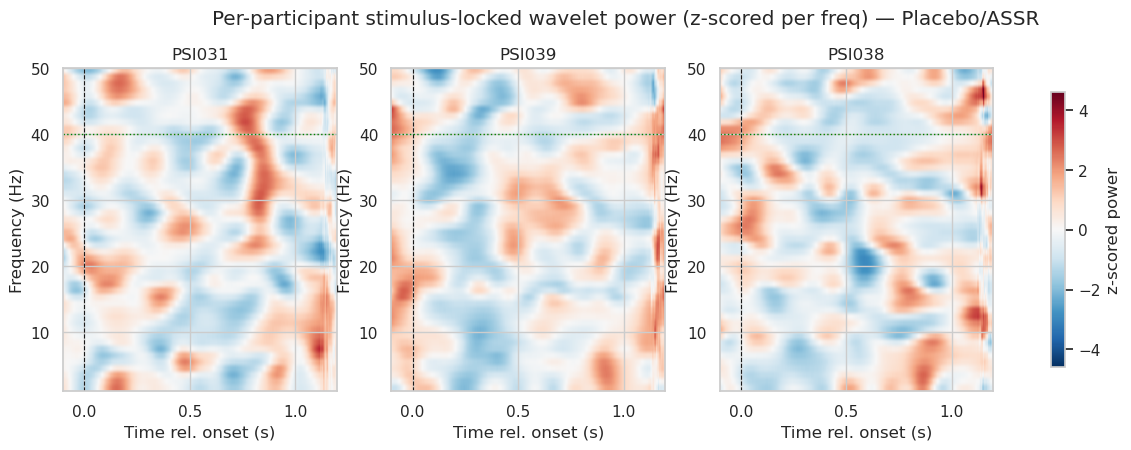

In [9]:
power_maps = {}    # subject idx -> (n_freqs, win) raw mean power
tf_z = {}          # subject idx -> (n_freqs, win) per-frequency z-scored power
for k, si in enumerate(SUBJECT_INDICES):
    ep, n_used_w = epoch_average(wav[k], onsets, PRE, POST)   # (n_ch, n_freqs, win)
    m = ep.mean(axis=0)                                       # avg channels -> (n_freqs, win)
    power_maps[si] = m
    tf_z[si] = zscore(m, axis=1)                              # z-score per freq over time
print(f"Averaged {n_used_w} stimuli per participant (wavelet).")

# Shared colour scale across the per-participant panels for comparability.
vmax = max(np.abs(tf_z[si]).max() for si in SUBJECT_INDICES)
vmin = -vmax
extent = [epoch_times[0], epoch_times[-1], wavelet_freqs[0], wavelet_freqs[-1]]

fig, axes = plt.subplots(
    1, len(SUBJECT_INDICES), figsize=(5 * len(SUBJECT_INDICES), 4.2), squeeze=False
)
for ax, si, label in zip(axes[0], SUBJECT_INDICES, subject_labels):
    im = ax.imshow(tf_z[si], aspect="auto", origin="lower", extent=extent,
                   cmap="RdBu_r", vmin=vmin, vmax=vmax)
    ax.axvline(0.0, color="k", ls="--", lw=0.8)
    ax.axhline(ASSR_FREQ, color="green", ls=":", lw=1.0)
    ax.set_title(label)
    ax.set_xlabel("Time rel. onset (s)")
    ax.set_ylabel("Frequency (Hz)")
fig.colorbar(im, ax=axes[0].tolist(), shrink=0.85, label="z-scored power")
fig.suptitle(
    f"Per-participant stimulus-locked wavelet power (z-scored per freq) — "
    f"{CONDITION.value}/{MUSIC_TYPE.value}", y=1.02
)
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "wavelet_tf_per_participant.png", dpi=150,
                bbox_inches="tight")
plt.show()

### Wavelet Power — averaged over participants

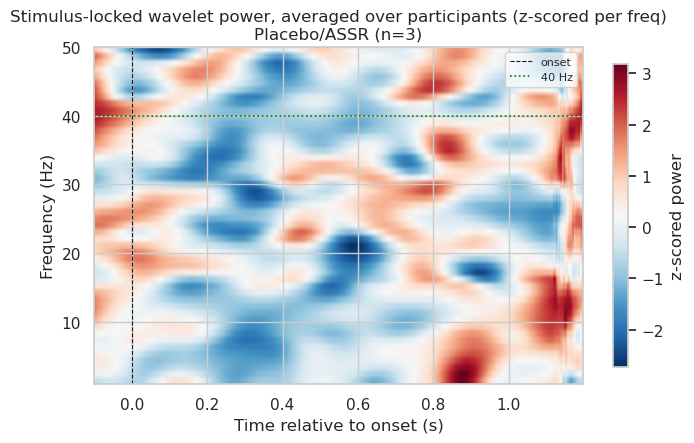

In [10]:
group_power = np.mean([power_maps[si] for si in SUBJECT_INDICES], axis=0)
group_tf_z = zscore(group_power, axis=1)             # z-score per freq over time

fig, ax = plt.subplots(figsize=(7, 4.6))
im = ax.imshow(group_tf_z, aspect="auto", origin="lower", extent=extent,
               cmap="RdBu_r")
ax.axvline(0.0, color="k", ls="--", lw=0.8, label="onset")
ax.axhline(ASSR_FREQ, color="green", ls=":", lw=1.2, label=f"{ASSR_FREQ:.0f} Hz")
ax.set_title(
    f"Stimulus-locked wavelet power, averaged over participants (z-scored per "
    f"freq)\n{CONDITION.value}/{MUSIC_TYPE.value} (n={len(SUBJECT_INDICES)})"
)
ax.set_xlabel("Time relative to onset (s)")
ax.set_ylabel("Frequency (Hz)")
ax.legend(loc="upper right", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.9, label="z-scored power")
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "wavelet_tf_group_average.png", dpi=150)
plt.show()

## Per-Participant 40 Hz ASSR Time Course (outlier check)

A focused view: the power in the ASSR band (around `ASSR_FREQ`) over the epoch, one
line per participant plus the group mean. A participant whose 40 Hz response is
flat, delayed, or extreme stands out here even when the full TF map looks busy.

ASSR band: [38. 39. 40. 41. 42.] Hz


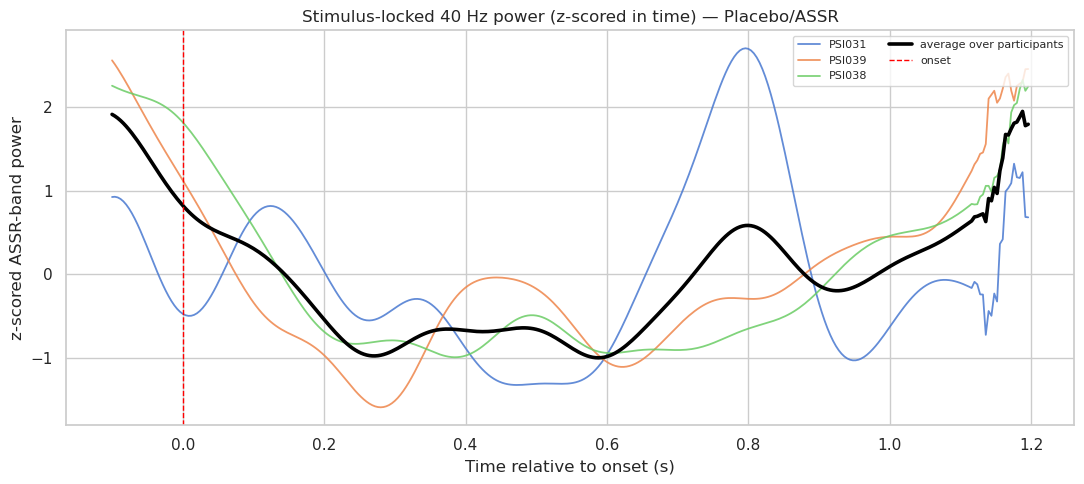

In [11]:
band = (wavelet_freqs >= ASSR_FREQ - 2) & (wavelet_freqs <= ASSR_FREQ + 2)
print(f"ASSR band: {wavelet_freqs[band]} Hz")

fig, ax = plt.subplots(figsize=(11, 5))
band_curves = {}
for si, label in zip(SUBJECT_INDICES, subject_labels):
    curve = zscore(power_maps[si][band].mean(axis=0))    # band-mean, z-scored in time
    band_curves[si] = curve
    ax.plot(epoch_times, curve, lw=1.3, alpha=0.85, label=label)
group_band = np.mean([band_curves[si] for si in SUBJECT_INDICES], axis=0)
ax.plot(epoch_times, group_band, lw=2.6, color="black",
        label="average over participants")
ax.axvline(0.0, color="red", ls="--", lw=1, label="onset")
ax.set_title(
    f"Stimulus-locked {ASSR_FREQ:.0f} Hz power (z-scored in time) — "
    f"{CONDITION.value}/{MUSIC_TYPE.value}"
)
ax.set_xlabel("Time relative to onset (s)")
ax.set_ylabel("z-scored ASSR-band power")
ax.legend(loc="upper right", fontsize=8, ncol=2)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "wavelet_assr_band_timecourse.png", dpi=150)
plt.show()

## Stimulus-Locked Topomaps (z-scored wavelet power)

Spatial map of the stimulus-locked **z-scored wavelet power** across **all 195
electrodes** (following the notebook-05 topomap convention — signed values,
diverging `RdBu_r`, symmetric colour scale). For every participant and channel the
wavelet power is z-scored in time over the whole recording, epoched around each
`fam+` onset and averaged over stimuli, then mean-collapsed over the selected
frequencies (`TOPO_FREQ_RANGE`) and the post-onset window `[TOPO_TMIN, TOPO_TMAX]`
s — **no powering or sqrt**. Red = power above the recording mean during the
response, blue = below. The final panel is the **average over participants**; a
participant whose scalp topography differs markedly is a candidate outlier.

These per-channel values were reduced for *all* channels during the wavelet
streaming pass above (`wav_topo`). Electrode positions come from the `RAW_CROPPED`
montage (same channel order as the concatenated array).

In [12]:
# Electrode positions: one RAW_CROPPED recording's Info (eeg picks already in the
# same channel order as the concatenated array / channel_names).
topo_handler = DatasetHandler(EXPERIMENT, CoordinateSystems.HYDROGEL_257_NO_FIDUCIALS)
info_fname = meta.loc[
    meta[pidx_col] == SUBJECT_INDICES[0], "SingleDataMetadata.FILENAME"
].iloc[0]
topo_info = (
    topo_handler.load_data_file(
        info_fname,
        is_processed=True,
        processed_data_type=PreprocessedDataVariants.RAW_CROPPED,
        preload=False,
    )
    .pick("eeg")
    .info
)
# Map our canonical channel order onto the Info channel order (defensive; matches).
name_pos = {n: i for i, n in enumerate(channel_names)}
assert set(topo_info["ch_names"]) <= set(name_pos), (
    "RAW_CROPPED channels are not a subset of the concatenated channel names."
)
info_order = [name_pos[n] for n in topo_info["ch_names"]]

group_topo = np.mean([wav_topo[si] for si in SUBJECT_INDICES], axis=0)
print(f"Topomap scalar: z-scored wavelet power, {TOPO_FREQ_RANGE[0]:.0f}-"
      f"{TOPO_FREQ_RANGE[1]:.0f} Hz, [{TOPO_TMIN}, {TOPO_TMAX}] s "
      f"(signed mean, no RMS).")

Topomap scalar: z-scored wavelet power, 1-50 Hz, [0.0, 1.2] s (signed mean, no RMS).


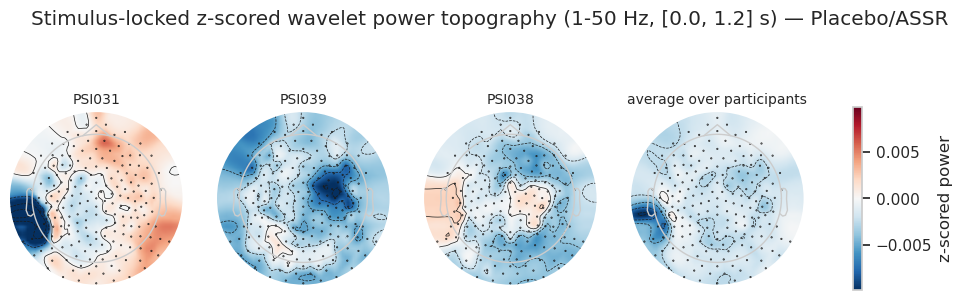

In [13]:
panels = [(subject_labels[k], wav_topo[si][info_order])
          for k, si in enumerate(SUBJECT_INDICES)]
panels.append(("average over participants", group_topo[info_order]))

# Symmetric, shared scale (nb05 convention): 99th percentile of |value|.
vlim = float(np.percentile(np.abs(np.concatenate([v for _, v in panels])), 99))
if vlim == 0.0:
    vlim = 1e-12

fig, axes = plt.subplots(1, len(panels), figsize=(3.2 * len(panels), 3.4),
                         squeeze=False)
im = None
for ax, (label, vals) in zip(axes[0], panels):
    im, _ = mne.viz.plot_topomap(
        vals, topo_info, axes=ax, show=False, cmap="RdBu_r",
        vlim=(-vlim, vlim), contours=4,
    )
    ax.set_title(label, fontsize=10)
fig.colorbar(im, ax=axes[0].tolist(), shrink=0.7, label="z-scored power")
fig.suptitle(
    f"Stimulus-locked z-scored wavelet power topography "
    f"({TOPO_FREQ_RANGE[0]:.0f}-{TOPO_FREQ_RANGE[1]:.0f} Hz, "
    f"[{TOPO_TMIN}, {TOPO_TMAX}] s) — {CONDITION.value}/{MUSIC_TYPE.value}",
    y=1.05,
)
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "wavelet_stimulus_locked_topomaps.png", dpi=150,
                bbox_inches="tight")
plt.show()